In [1]:
%matplotlib inline

import numpy as np
import visualization as vs
import util as ut
import matplotlib.pyplot as plt
import pandas as pd
import MDP_algorithms.mdp_state_action as mdp
import MDP_algorithms.value_iteration as vi
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import potential_games as game
import time
from itertools import product
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
import tracemalloc

from global_util import Global_MDP
from global_util_augmented import Global_MDP_aug

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3 6]
Starting nodes: [1 5 8]
Time to construct sparse joint P: 3.05 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 101.91 seconds.
Potential value: 0.8786508336073335
Collision Likelihood 0.09814416390904179
Reach reduction: 0.9422306513223344


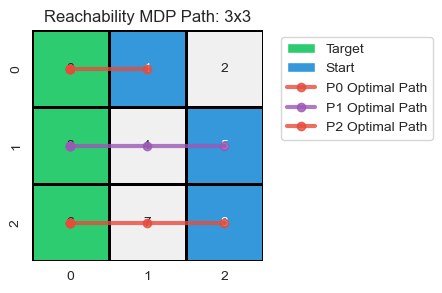

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3 6]
Starting nodes: [1 5 8]
Time to construct sparse joint P: 3.46 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 95.13 seconds.
Potential value: 0.8747129982052463
Collision Likelihood 0.03876605160490709
Reach reduction: 0.9380078712670584


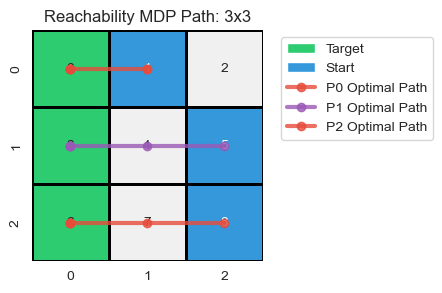

[(1, 5, 8), (1, 4, 7), (0, 3, 6), (0, 3, 6), (0, 3, 6), (0, 3, 6)]

In [7]:
# The augmentation to the MDP is as follows: At terminal state T, target states = 2.0, all other safe states = 1.0, collision states are 0.0

# Toy problem comparing original global MDP with augmented global MDP


Columns = 3
Rows = 3
T = 5
player_num = 3
action_entropy = 0.9


targs_x0s_normal = np.array([0,3,6,1,5,8])

test_normal = Global_MDP(Rows,Columns,T,player_num)
test_normal.create_joint_MDP(action_entropy, targs_x0s_normal)

test_normal.global_value_iteration()

test_normal.get_potential()
print('Potential value:', test_normal.potential_value)
test_normal.get_collision_likelihood()
print('Collision Likelihood',test_normal.collision_likelihood)
test_normal.get_reach_reduction()
print('Reach reduction:',test_normal.reach_reduction)

test_normal.highest_prob_trajectory()
test_normal.plot_occupancy_grid()
test_normal.traj

test_normal_aug = Global_MDP_aug(Rows,Columns,T,player_num)
test_normal_aug.create_joint_MDP(action_entropy, targs_x0s_normal)

test_normal_aug.global_value_iteration()

test_normal_aug.get_potential()
print('Potential value:', test_normal_aug.potential)
test_normal_aug.get_collision_likelihood()
print('Collision Likelihood',test_normal_aug.collision_likelihood)
test_normal_aug.get_reach_reduction()
print('Reach reduction:',test_normal_aug.reach_reduction)

test_normal_aug.highest_prob_trajectory()
test_normal_aug.plot_occupancy_grid()
test_normal_aug.traj

Starting local MDP construction...
----------------------------------------
Target nodes:  [0 4]
Starting nodes:[24 20]
Time to construct local MDP: 0.0 seconds.
----------------------------------------
Starting iterative best response (Algorithm 3)...

BR iteration 1, updating player 0...

BR iteration 1, updating player 1...
  Potential = 0.00766382, delta = inf

BR iteration 2, updating player 0...

BR iteration 2, updating player 1...
  Potential = 0.00785366, delta = 0.00018984

BR iteration 3, updating player 0...

BR iteration 3, updating player 1...
  Potential = 0.00785366, delta = 0.0
  Converged after 3 full rounds.

Time for local value iteration: 0.6 seconds.


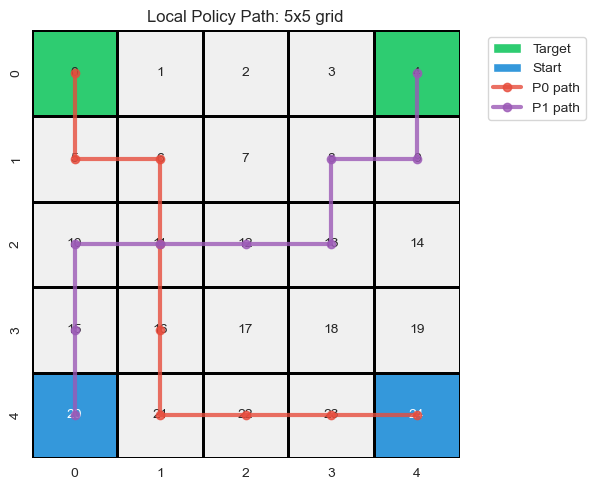

Starting local MDP construction...
----------------------------------------
Target nodes:  [0 4]
Starting nodes:[24 20]
Time to construct local MDP: 0.0 seconds.
----------------------------------------
Starting iterative best response (Algorithm 3)...

BR iteration 1, updating player 0...

BR iteration 1, updating player 1...
  Potential = 0.9803935, delta = inf

BR iteration 2, updating player 0...

BR iteration 2, updating player 1...
  Potential = 0.98350001, delta = 0.00310651

BR iteration 3, updating player 0...

BR iteration 3, updating player 1...
  Potential = 0.99526689, delta = 0.01176689

BR iteration 4, updating player 0...

BR iteration 4, updating player 1...
  Potential = 0.99589694, delta = 0.00063005

BR iteration 5, updating player 0...

BR iteration 5, updating player 1...
  Potential = 0.99589803, delta = 1.09e-06
  Converged after 5 full rounds.

Time for local value iteration: 3.72 seconds.


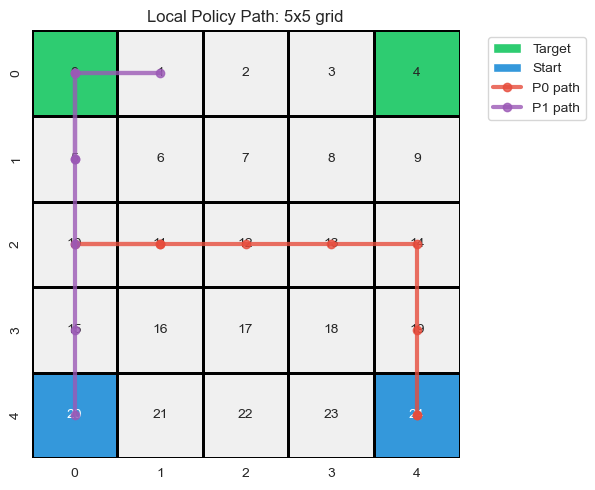

In [3]:
from local_util import Local_MDP,Local_MDP_aug

Columns = 5
Rows = 5
T = 8
player_num = 2
action_entropy = 0.6


targs_x0s_normal = np.array([0,4,24,20])

test_local = Local_MDP(Rows,Columns,T,player_num)
test_local.create_MDP(action_entropy, targs_x0s_normal)

test_local.local_value_iteration()

test_local.get_all_metrics()
test_local.potential_value
test_local.collision_likelihood

test_local.highest_prob_trajectory()
test_local.plot_occupancy_grid()
# test_local.traj

# --------------------------------------------------------------------

test_local_aug = Local_MDP_aug(Rows,Columns,T,player_num)
test_local_aug.create_MDP(action_entropy, targs_x0s_normal)

test_local_aug.local_value_iteration()

test_local_aug.get_all_metrics()
test_local_aug.potential_value
test_local_aug.collision_likelihood

test_local_aug.highest_prob_trajectory()
test_local_aug.plot_occupancy_grid()
# test_local_aug.traj
